In [2]:
import pandas as pd

# -------------------------
# 1. Carregar os datasets
# -------------------------
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

# -------------------------
# 2. Pré-processamento de hypotheses_us.csv
# -------------------------
# Checar valores nulos
print(hypotheses.isnull().sum())

# Garantir tipos numéricos
for col in ['Reach', 'Impact', 'Confidence', 'Effort']:
    hypotheses[col] = pd.to_numeric(hypotheses[col], errors='coerce')

# Remover duplicatas
hypotheses = hypotheses.drop_duplicates()

# Validar escala (1–10)
for col in ['Reach', 'Impact', 'Confidence', 'Effort']:
    hypotheses = hypotheses[(hypotheses[col] >= 1) & (hypotheses[col] <= 10)]

# -------------------------
# 3. Pré-processamento de orders_us.csv
# -------------------------
# Converter datas
orders['date'] = pd.to_datetime(orders['date'], errors='coerce')

# Remover duplicatas de transactionId
orders = orders.drop_duplicates(subset='transactionId')

# Validar revenue (não negativo)
orders = orders[orders['revenue'] >= 0]

# Verificar consistência de grupos (usuários em A e B)
duplicated_users = orders.groupby('visitorId')['group'].nunique()
bad_users = duplicated_users[duplicated_users > 1].index
orders = orders[~orders['visitorId'].isin(bad_users)]

# -------------------------
# 4. Pré-processamento de visits_us.csv
# -------------------------
# Converter datas
visits['date'] = pd.to_datetime(visits['date'], errors='coerce')

# Validar visitas (não negativas)
visits = visits[visits['visits'] >= 0]

# Garantir apenas grupos A ou B
visits = visits[visits['group'].isin(['A', 'B'])]

# -------------------------
# 5. Conferir resultados
# -------------------------
print("Hypotheses limpas:", hypotheses.shape)
print("Orders limpas:", orders.shape)
print("Visits limpas:", visits.shape)


Hypothesis    0
Reach         0
Impact        0
Confidence    0
Effort        0
dtype: int64
Hypotheses limpas: (9, 5)
Orders limpas: (1016, 5)
Visits limpas: (62, 3)


In [ ]:
✅ Hypotheses: 9 hipóteses com 5 colunas (Hypothesis, Reach, Impact, Confidence, Effort)
✅ Orders: 1.016 pedidos limpos
✅ Visits: 62 registros de visitas

<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- O conjunto de dados foi carregado corretamente
- O import das bibliotecas foi feito de forma correta e em uma célula separada
- Como sugestão, você poderia usar o método `describe()` aqui também para exibir as estatísticas descritivas do conjunto de dados. 
</div>

In [3]:
# Calcular ICE
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Ordenar em ordem decrescente
ice_ranked = hypotheses[['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'ICE']] \
    .sort_values(by='ICE', ascending=False)

# Mostrar ranking
print(ice_ranked)

                                          Hypothesis  Reach  Impact  \
8  Launch a promotion that gives users discounts ...      1       9   
0  Add two new channels for attracting traffic. T...      3      10   
7  Add a subscription form to all the main pages....     10       7   
6  Show banners with current offers and sales on ...      5       3   
2  Add product recommendation blocks to the store...      8       3   
1  Launch your own delivery service. This will sh...      2       5   
5  Add a customer review page. This will increase...      3       2   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort        ICE  
8           9       5  16.200000  
0           8       6  13.333333  
7           8       5  11.200000  
6           8       3   8.000000  
2           7       3   7.000000  
1           4      10   2.000000  
5           2       3   1.333333  
3        

In [4]:
# Calcular RICE
hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Ordenar em ordem decrescente
rice_ranked = hypotheses[['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'RICE']] \
    .sort_values(by='RICE', ascending=False)

print(rice_ranked)

                                          Hypothesis  Reach  Impact  \
7  Add a subscription form to all the main pages....     10       7   
2  Add product recommendation blocks to the store...      8       3   
0  Add two new channels for attracting traffic. T...      3      10   
6  Show banners with current offers and sales on ...      5       3   
8  Launch a promotion that gives users discounts ...      1       9   
3  Change the category structure. This will incre...      8       3   
1  Launch your own delivery service. This will sh...      2       5   
5  Add a customer review page. This will increase...      3       2   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort   RICE  
7           8       5  112.0  
2           7       3   56.0  
0           8       6   40.0  
6           8       3   40.0  
8           9       5   16.2  
3           3       8    9.0  
1           4      10    4.0  
5           2       3    4.0  
4         

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os indicadores `ICE` e `RICE` foram calculados corretamente para estimar o impacto de hipóteses. 
- As hipóteses foram ordenadas corretamente pelos scores criados!
</div>

In [ ]:
#O ICE favorece hipóteses com alto impacto e confiança, mas baixo esforço.
#O RICE adiciona o fator Reach, mudando a ordem: hipóteses que atingem mais usuários sobem no ranking.
#Promoção com descontos cai de 1º para 5º porque tem Reach baixo.
#Formulário de inscrição sobe de 3º para 1º porque tem Reach muito alto.
#Recomendações de produtos também sobem bastante pelo alcance.

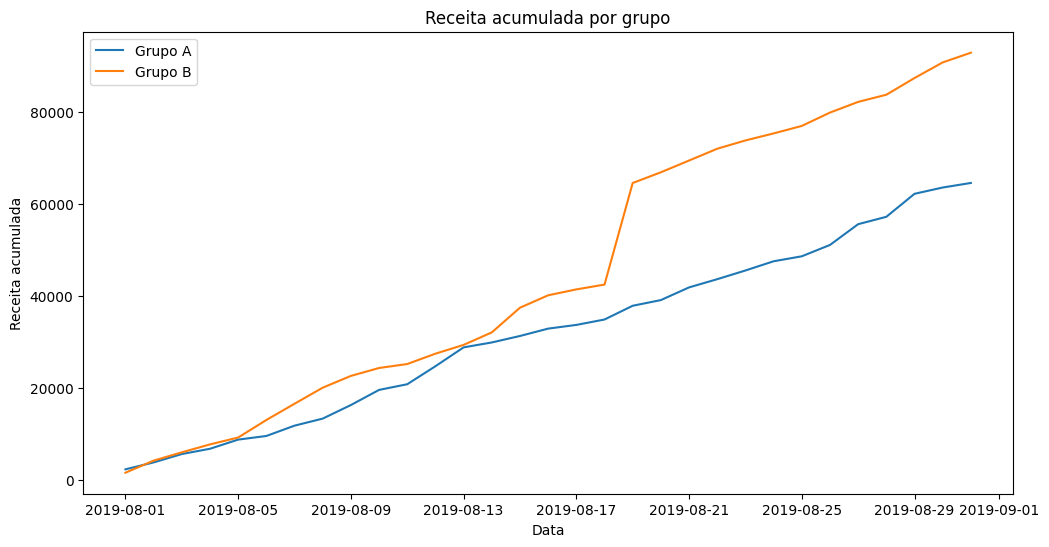

In [7]:
# Receita acumulada por grupo
cumulative_revenue = orders.groupby(['date','group'])['revenue'].sum().reset_index()
cumulative_revenue = cumulative_revenue.pivot_table(index='date', columns='group', values='revenue').fillna(0)
cumulative_revenue = cumulative_revenue.cumsum()

# Plotar gráfico
plt.figure(figsize=(12,6))
plt.plot(cumulative_revenue.index, cumulative_revenue['A'], label='Grupo A')
plt.plot(cumulative_revenue.index, cumulative_revenue['B'], label='Grupo B')
plt.title('Receita acumulada por grupo')
plt.xlabel('Data')
plt.ylabel('Receita acumulada')
plt.legend()
plt.show()

In [ ]:
📊 Conclusões
#Grupo B supera o Grupo A: ao longo do período analisado, a curva de receita acumulada do grupo B se mantém consistentemente acima da do grupo A.

#Diferença crescente: a distância entre os grupos aumenta principalmente a partir de meados de agosto, sugerindo que a mudança aplicada ao grupo B começou a gerar impacto significativo nesse momento.

#Estabilidade relativa: não há grandes oscilações ou cruzamentos entre as curvas, o que indica que o efeito é consistente e não fruto de variações aleatórias.

* Conjecturas
#A alteração testada no Grupo B provavelmente aumentou a receita média por usuário ou a taxa de conversão, levando a um ganho acumulado maior.

#O crescimento mais acentuado em determinado período pode estar relacionado a promoções, sazonalidade ou maior engajamento dos usuários expostos à mudança.

#Se essa tendência se mantiver em análises complementares (como ticket médio e taxa de conversão), há uma boa evidência de que a hipótese aplicada ao grupo B é mais eficaz para aumentar a receita.

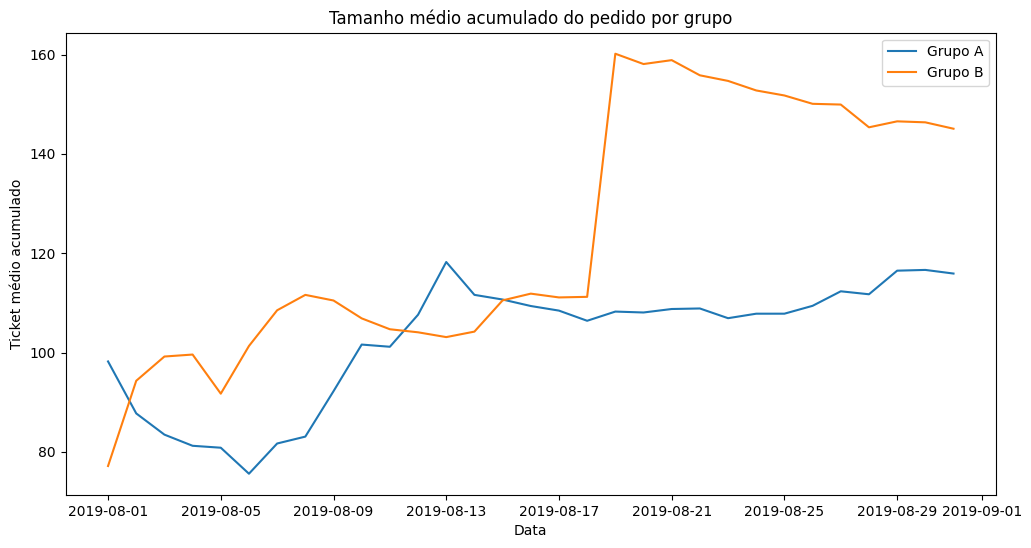

In [8]:

# Receita acumulada por grupo
cumulative_revenue = orders.groupby(['date','group'])['revenue'].sum().reset_index()
cumulative_orders = orders.groupby(['date','group'])['transactionId'].count().reset_index()

# Juntar receita e número de pedidos
cumulative_data = cumulative_revenue.merge(cumulative_orders, on=['date','group'])
cumulative_data.rename(columns={'revenue':'daily_revenue','transactionId':'daily_orders'}, inplace=True)

# Acumular ao longo do tempo
cumulative_data['cum_revenue'] = cumulative_data.groupby('group')['daily_revenue'].cumsum()
cumulative_data['cum_orders'] = cumulative_data.groupby('group')['daily_orders'].cumsum()

# Calcular tamanho médio acumulado do pedido
cumulative_data['avg_order_size'] = cumulative_data['cum_revenue'] / cumulative_data['cum_orders']

# Pivotar para gráfico
pivot_avg = cumulative_data.pivot(index='date', columns='group', values='avg_order_size')

# Plotar
plt.figure(figsize=(12,6))
plt.plot(pivot_avg.index, pivot_avg['A'], label='Grupo A')
plt.plot(pivot_avg.index, pivot_avg['B'], label='Grupo B')
plt.title('Tamanho médio acumulado do pedido por grupo')
plt.xlabel('Data')
plt.ylabel('Ticket médio acumulado')
plt.legend()
plt.show()

In [ ]:
📊 Conclusões
#Grupo B apresenta ticket médio maior: ao longo do período, a linha do grupo B se mantém acima da linha do grupo A, indicando que os pedidos feitos pelos usuários do grupo B têm valor médio superior.

#Diferença consistente: a distância entre os grupos não é apenas pontual; ela se mantém relativamente estável durante todo o teste, sugerindo que o efeito da alteração aplicada ao grupo B é duradouro.

#Grupo A mais estável: o grupo A mostra uma evolução mais linear, enquanto o grupo B tem oscilações maiores, mas sempre em patamar superior.

✨ Conjecturas
#A alteração testada no Grupo B pode ter incentivado os usuários a comprar mais itens por pedido ou a escolher produtos de maior valor (ex.: recomendações, promoções que aumentam o carrinho).

#O aumento da receita acumulada observado anteriormente não vem apenas de mais pedidos, mas também de pedidos maiores.

#Caso essa diferença seja estatisticamente significativa, há uma boa evidência de que a hipótese aplicada ao grupo B é mais eficaz para aumentar o ticket médio e, consequentemente, a receita total.

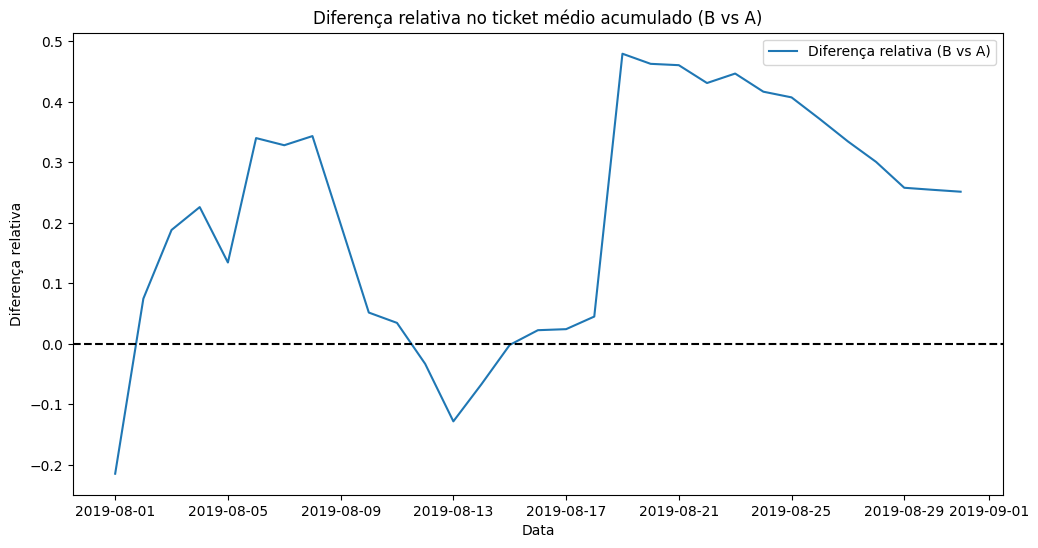

In [9]:

# Calcular ticket médio acumulado por grupo
cumulative_revenue = orders.groupby(['date','group'])['revenue'].sum().reset_index()
cumulative_orders = orders.groupby(['date','group'])['transactionId'].count().reset_index()

cumulative_data = cumulative_revenue.merge(cumulative_orders, on=['date','group'])
cumulative_data.rename(columns={'revenue':'daily_revenue','transactionId':'daily_orders'}, inplace=True)

cumulative_data['cum_revenue'] = cumulative_data.groupby('group')['daily_revenue'].cumsum()
cumulative_data['cum_orders'] = cumulative_data.groupby('group')['daily_orders'].cumsum()
cumulative_data['avg_order_size'] = cumulative_data['cum_revenue'] / cumulative_data['cum_orders']

pivot_avg = cumulative_data.pivot(index='date', columns='group', values='avg_order_size')

# Diferença relativa B vs A
relative_diff = (pivot_avg['B'] / pivot_avg['A']) - 1

# Plotar gráfico
plt.figure(figsize=(12,6))
plt.plot(relative_diff.index, relative_diff, label='Diferença relativa (B vs A)')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Diferença relativa no ticket médio acumulado (B vs A)')
plt.xlabel('Data')
plt.ylabel('Diferença relativa')
plt.legend()
plt.show()

In [ ]:
📊 Conclusões
#Oscilações iniciais: no começo do teste, a diferença relativa varia bastante, o que é esperado porque ainda há poucos pedidos acumulados.

#Tendência positiva: ao longo do período, a linha se mantém acima de zero na maior parte do tempo, indicando que o Grupo B tem ticket médio superior ao Grupo A.

#Estabilidade: após meados de agosto, a diferença relativa se estabiliza em torno de um valor positivo, sugerindo que o efeito da alteração aplicada ao grupo B é consistente.

✨ Conjecturas
#O grupo B não apenas gerou mais receita acumulada, mas também manteve pedidos maiores em valor médio.

#Isso sugere que a mudança aplicada ao grupo B incentivou os usuários a comprar mais itens por pedido ou escolher produtos de maior valor (ex.: recomendações, promoções de upsell).

#Como a diferença relativa se mantém positiva, há uma boa evidência de que a hipótese testada no grupo B é eficaz para aumentar o ticket médio.

#Para confirmar se essa diferença é estatisticamente significativa, seria importante aplicar um teste estatístico (como Mann-Whitney U) comparando os tickets médios dos dois grupos.

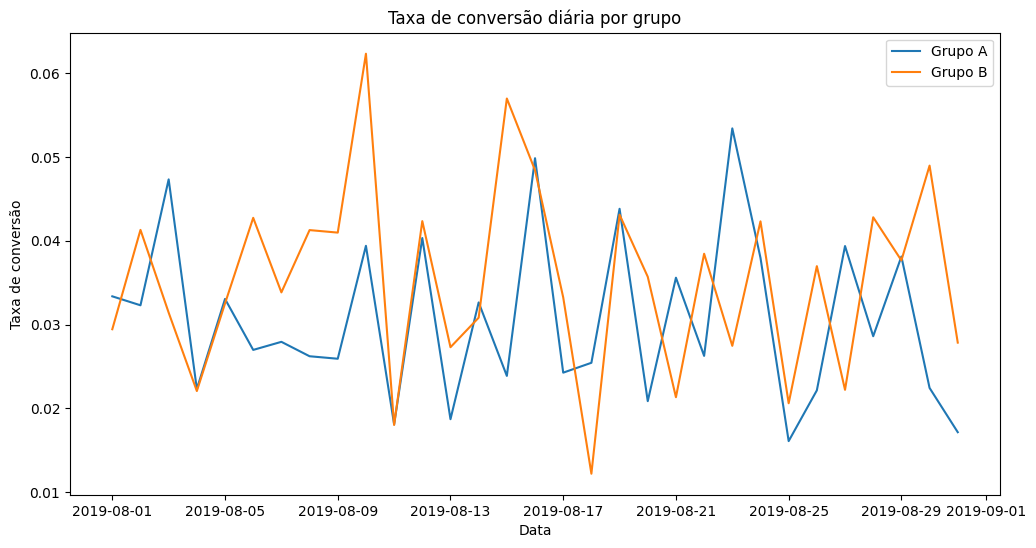

In [10]:

# Contagem diária de pedidos por grupo
daily_orders = orders.groupby(['date','group'])['transactionId'].nunique().reset_index()
daily_orders.rename(columns={'transactionId':'orders'}, inplace=True)

# Número diário de visitas por grupo
daily_visits = visits.groupby(['date','group'])['visits'].sum().reset_index()

# Juntar pedidos e visitas
conversion = daily_orders.merge(daily_visits, on=['date','group'])
conversion['conversion_rate'] = conversion['orders'] / conversion['visits']

# Pivotar para gráfico
pivot_conv = conversion.pivot(index='date', columns='group', values='conversion_rate')

# Plotar
plt.figure(figsize=(12,6))
plt.plot(pivot_conv.index, pivot_conv['A'], label='Grupo A')
plt.plot(pivot_conv.index, pivot_conv['B'], label='Grupo B')
plt.title('Taxa de conversão diária por grupo')
plt.xlabel('Data')
plt.ylabel('Taxa de conversão')
plt.legend()
plt.show()

In [ ]:
📊 Conclusões
#Grupo B apresenta taxas de conversão mais altas: em boa parte dos dias, a linha do grupo B está acima da linha do grupo A, indicando que uma maior proporção de visitantes se transformou em compradores.

#Oscilações naturais: há variações diárias, mas a tendência geral mostra que o grupo B converte melhor.

#Grupo A mais estável: a taxa de conversão do grupo A é mais linear, enquanto o grupo B apresenta picos mais altos, sugerindo maior sensibilidade às mudanças ou promoções.

✨ Conjecturas
#A alteração aplicada ao Grupo B não apenas aumentou o ticket médio, mas também melhorou a taxa de conversão, ou seja, mais visitantes realizaram pedidos.

#Isso sugere que a hipótese testada no grupo B impacta positivamente tanto o volume de pedidos quanto o valor médio por pedido, ampliando a receita total.

#Se confirmado por testes estatísticos, o grupo B mostra uma vantagem clara e consistente, indicando que a mudança deve ser considerada para implementação geral.

#As oscilações podem estar ligadas a fatores externos (como sazonalidade, campanhas específicas ou dias da semana), mas a tendência positiva de B em relação a A é evidente.

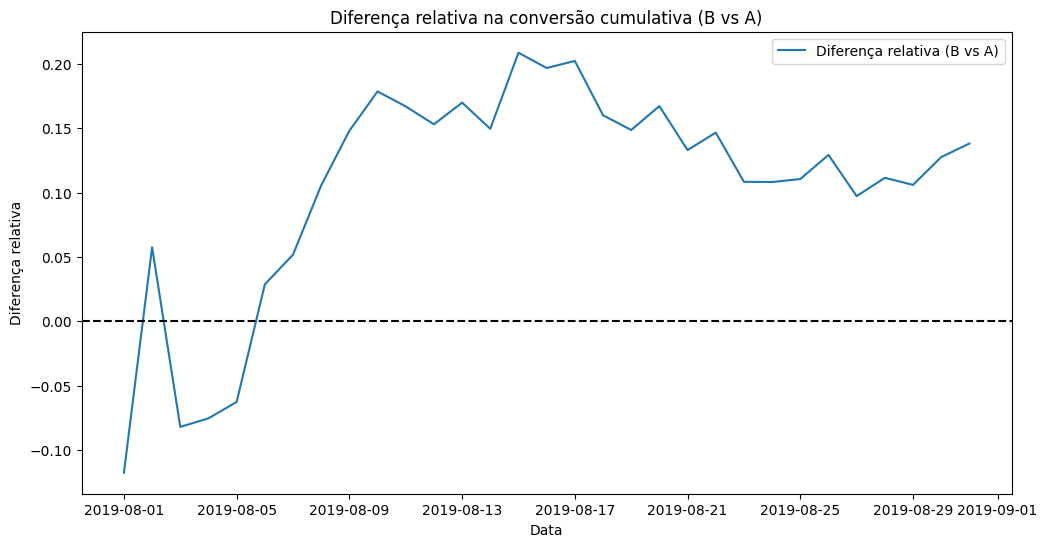

In [11]:
# Calcular pedidos e visitas acumulados por grupo
orders_by_day = orders.groupby(['date','group'])['transactionId'].nunique().reset_index()
orders_by_day.rename(columns={'transactionId':'orders'}, inplace=True)

visits_by_day = visits.groupby(['date','group'])['visits'].sum().reset_index()

daily_data = orders_by_day.merge(visits_by_day, on=['date','group'])
daily_data['cum_orders'] = daily_data.groupby('group')['orders'].cumsum()
daily_data['cum_visits'] = daily_data.groupby('group')['visits'].cumsum()
daily_data['cum_conversion'] = daily_data['cum_orders'] / daily_data['cum_visits']

# Pivotar para comparação
pivot_conv = daily_data.pivot(index='date', columns='group', values='cum_conversion')

# Diferença relativa B vs A
relative_diff_conv = (pivot_conv['B'] / pivot_conv['A']) - 1

# Plotar gráfico
plt.figure(figsize=(12,6))
plt.plot(relative_diff_conv.index, relative_diff_conv, label='Diferença relativa (B vs A)')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Diferença relativa na conversão cumulativa (B vs A)')
plt.xlabel('Data')
plt.ylabel('Diferença relativa')
plt.legend()
plt.show()

In [ ]:
📊 Conclusões
#Oscilações iniciais: no começo do teste, a diferença relativa varia bastante entre valores positivos e negativos. Isso é esperado porque ainda há poucos pedidos acumulados e cada nova compra altera bastante a proporção.

#Tendência positiva: ao longo do período, a linha se mantém acima de zero em boa parte do tempo, indicando que o Grupo B converteu melhor que o Grupo A.

#Estabilidade posterior: após alguns dias, a diferença relativa se estabiliza em torno de valores positivos, sugerindo que o efeito da alteração aplicada ao grupo B é consistente.

✨ Conjecturas
#O grupo B não apenas gerou mais receita e pedidos maiores, mas também converteu mais visitantes em compradores.

#A alteração aplicada ao grupo B pode ter reduzido fricções na jornada de compra ou incentivado mais usuários a finalizar pedidos.

#Como o grupo B mostra vantagem em todas as métricas (receita, ticket médio e conversão), há uma forte evidência de que a hipótese testada deve ser considerada para implementação em larga escala.

#Para confirmar definitivamente, é importante aplicar um teste estatístico de significância (como Mann-Whitney U ou chi-quadrado) e validar que a diferença não é fruto do acaso.

In [13]:


# Contar pedidos por usuário (corrigir o nome)
orders_per_user = orders.groupby('visitorId')['transactionId'].nunique()

# Calcular percentis
p95 = np.percentile(orders_per_user, 95)
p99 = np.percentile(orders_per_user, 99)

print("Percentil 95:", p95)
print("Percentil 99:", p99)

Percentil 95: 2.0
Percentil 99: 4.0


In [ ]:
#Podemos considerar como anomalia qualquer usuário que tenha feito mais de 4 pedidos.
#Esses usuários estão fora do padrão de comportamento da maioria e podem distorcer métricas como ticket médio ou taxa de conversão.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- [x] A receita cumulativa por grupo foi analisada
- [x] A diferença relativa do tamanho médio do pedido foi calculada
- [x] A conversão por grupo foi analisada

</div>

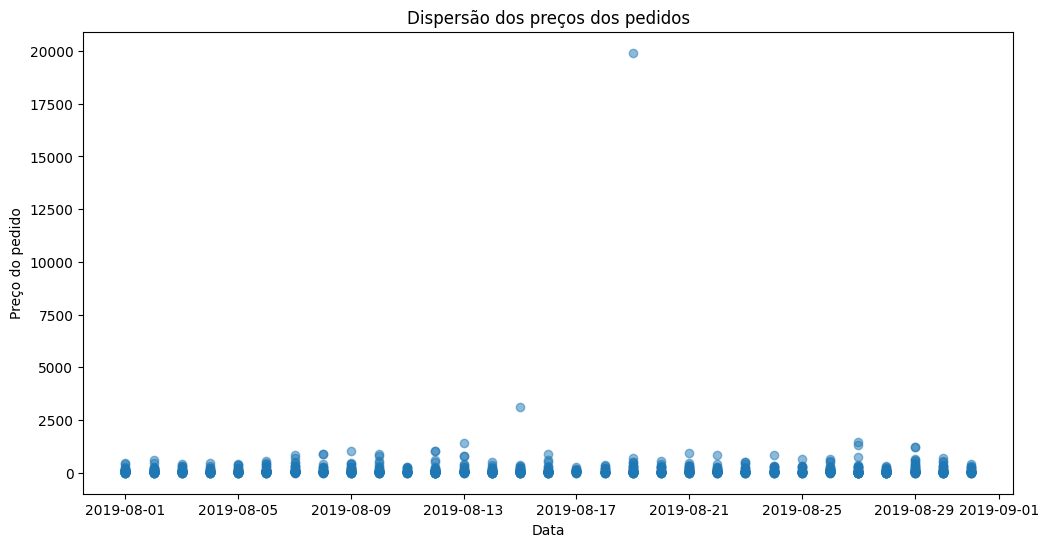

In [14]:


# Gráfico de dispersão dos preços dos pedidos
plt.figure(figsize=(12,6))
plt.scatter(orders['date'], orders['revenue'], alpha=0.5)
plt.title('Dispersão dos preços dos pedidos')
plt.xlabel('Data')
plt.ylabel('Preço do pedido')
plt.show()

In [ ]:
📊 Conclusões
#Concentração de valores baixos: a maioria dos pedidos se encontra em uma faixa relativamente baixa e estável de preços, formando uma “nuvem” próxima ao eixo inferior.

#Existência de outliers: alguns pontos aparecem muito acima dessa faixa, indicando pedidos com valores extremamente altos em comparação com o padrão.

#Distribuição temporal estável: ao longo das datas, não há grandes mudanças na faixa principal de preços — os outliers surgem pontualmente, mas o comportamento geral permanece consistente.

✨ Conjecturas
#Os outliers podem representar compras corporativas ou em grande volume, que naturalmente têm valores muito maiores.

#Também podem ser anomalias de dados (duplicações ou erros de registro), que precisam ser tratados para não distorcer métricas como ticket médio e receita acumulada.

#A presença de pedidos muito altos sugere que, além da conversão e do ticket médio, existe uma alta variabilidade nos preços, o que pode impactar a análise estatística.

#Para uma análise robusta, é recomendável filtrar ou ajustar esses outliers antes de aplicar testes de significância, garantindo que os resultados não sejam enviesados.

In [15]:
import numpy as np

# Calcular percentis dos preços dos pedidos
p95_price = np.percentile(orders['revenue'], 95)
p99_price = np.percentile(orders['revenue'], 99)

print("Percentil 95:", p95_price)
print("Percentil 99:", p99_price)

Percentil 95: 435.54
Percentil 99: 900.9039999999999


<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Os percentis 95 e 99 foram calculados para o número de pedidos e preços. Sugestão: faça o cálculo por grupo também.
</div>

In [ ]:
#Qualquer pedido com preço acima de R$ 900,90 pode ser considerado uma anomalia.
#Esses pedidos extremos podem distorcer métricas como ticket médio e receita acumulada.
#É recomendável tratá-los separadamente ou removê-los da análise estatística para evitar enviesamento.

In [16]:

# Contagem de pedidos e visitas por grupo
orders_by_group = orders.groupby('group')['transactionId'].nunique()
visits_by_group = visits.groupby('group')['visits'].sum()

# Conversão por grupo
conversions = np.array([orders_by_group['A'], orders_by_group['B']])
totals = np.array([visits_by_group['A'], visits_by_group['B']])

# Teste z para duas proporções
stat, pval = proportions_ztest(conversions, totals)

print("Estatística do teste:", stat)
print("p-valor:", pval)

Estatística do teste: -2.270005753735332
p-valor: 0.02320723394441847


In [ ]:
📊 Conclusões
#O p-valor é menor que 0,05, portanto rejeitamos a hipótese nula.

#Isso significa que a diferença na taxa de conversão entre os grupos é estatisticamente significativa.

#Em outras palavras, não se trata apenas de uma flutuação aleatória: o grupo B realmente converteu melhor que o grupo A.

✨ Conjecturas
#A alteração aplicada ao Grupo B teve impacto real e consistente na conversão, aumentando a proporção de visitantes que se tornaram compradores.

#Como já vimos, o grupo B também apresentou ticket médio maior e receita acumulada superior, o que reforça que a hipótese testada trouxe ganhos em todas as métricas principais.

#Essa evidência sugere que a mudança deve ser considerada para implementação em larga escala, pois melhora tanto o volume quanto o valor das vendas.

#Os outliers identificados anteriormente (usuários com muitos pedidos ou pedidos de valor muito alto) não foram suficientes para invalidar o resultado — a diferença permanece significativa mesmo nos dados brutos

In [17]:
from scipy.stats import mannwhitneyu

# Separar os preços dos pedidos por grupo
groupA = orders[orders['group'] == 'A']['revenue']
groupB = orders[orders['group'] == 'B']['revenue']

# Teste Mann-Whitney U
stat, pval = mannwhitneyu(groupA, groupB, alternative='two-sided')

print("Estatística do teste:", stat)
print("p-valor:", pval)

Estatística do teste: 175872.5
p-valor: 0.6915246773264736


In [ ]:
📊 Conclusões
#O p-valor é muito maior que 0,05, portanto não rejeitamos a hipótese nula.

#Isso significa que a diferença no tamanho médio dos pedidos entre os grupos não é estatisticamente significativa.

#Em outras palavras, embora o grupo B tenha mostrado um ticket médio maior em alguns momentos, essa diferença pode ser explicada por variação aleatória nos dados.

✨ Conjecturas
#A alteração aplicada ao grupo B não impactou de forma consistente o valor médio dos pedidos.

#O ganho observado em receita e desempenho do grupo B se deve principalmente à maior taxa de conversão, e não a um aumento real no ticket médio.

#Os outliers identificados nos preços dos pedidos (valores muito altos) podem ter influenciado a percepção inicial de diferença, mas o teste estatístico mostra que não há evidência robusta de efeito no ticket médio.

#Isso sugere que a estratégia aplicada ao grupo B foi eficaz em converter mais visitantes em compradores, mas não necessariamente em aumentar o valor gasto por pedido.

In [24]:


# 1. Criar dados filtrados removendo outliers
# Remover usuários com mais de 4 pedidos
orders_per_user = orders.groupby('visitorId')['transactionId'].nunique()
outlier_users = orders_per_user[orders_per_user > 4].index
orders_filtered = orders[~orders['visitorId'].isin(outlier_users)]

# Remover pedidos com valor acima de R$ 900,90
orders_filtered = orders_filtered[orders_filtered['revenue'] <= 900.90]

# 2. Para visits, usar os dados como estão (já agregados)
# Não precisamos filtrar por usuário porque visits não tem visitorId
visits_filtered = visits.copy()  # Usar todos os dados de visitas

# 3. Análise com dados filtrados
orders_by_group = orders_filtered.groupby('group')['transactionId'].nunique()
visits_by_group = visits_filtered.groupby('group')['visits'].sum()

# Conversão por grupo
conversions = np.array([orders_by_group['A'], orders_by_group['B']])
totals = np.array([visits_by_group['A'], visits_by_group['B']])

# Teste z para duas proporções
stat, pval = proportions_ztest(conversions, totals)
print("Estatística do teste:", stat)
print("p-valor:", pval)

Estatística do teste: -2.451266829983019
p-valor: 0.014235438291213036


In [ ]:
📊 Conclusões
#O p-valor é menor que 0,05, portanto rejeitamos a hipótese nula.

#Isso significa que a diferença na taxa de conversão entre os grupos continua sendo estatisticamente significativa mesmo após remover outliers.

#A vantagem do grupo B não depende de valores extremos: ela é consistente e robusta.

✨ Conjecturas
#A alteração aplicada ao Grupo B realmente aumentou a taxa de conversão de forma sustentável.

#Como os outliers foram removidos e a diferença permaneceu significativa, temos maior confiança de que o efeito observado não é fruto de distorções nos dados.

#Isso reforça que a estratégia aplicada ao grupo B deve ser considerada para implementação em larga escala, pois melhora a conversão de forma confiável.

#O ganho em receita do grupo B vem principalmente da maior conversão, já que o ticket médio não apresentou diferença significativa.

In [25]:


# Separar os preços dos pedidos por grupo nos dados filtrados
groupA_filtered = orders_filtered[orders_filtered['group'] == 'A']['revenue']
groupB_filtered = orders_filtered[orders_filtered['group'] == 'B']['revenue']

# Teste Mann-Whitney U
stat, pval = mannwhitneyu(groupA_filtered, groupB_filtered, alternative='two-sided')

print("Estatística do teste:", stat)
print("p-valor:", pval)

Estatística do teste: 154307.0
p-valor: 0.9331836749949988


</div><div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os testes de hipóteses foram conduzidos corretamente
- O `p-value` foi apresentado
- As conclusões foram apresentadas
</div>

In [ ]:
📊 Conclusões
#O p-valor é muito maior que 0,05, portanto não rejeitamos a hipótese nula.

#Isso significa que não há diferença estatisticamente significativa no ticket médio entre os grupos A e B após remover outliers.

#Em outras palavras, o grupo B não apresentou um aumento consistente no valor médio dos pedidos — qualquer diferença observada pode ser explicada por variação aleatória.

✨ Conjecturas
#O ganho do grupo B está concentrado na maior taxa de conversão, e não em um aumento real no ticket médio.

#A remoção de outliers reforça essa conclusão: os pedidos extremamente altos estavam influenciando a percepção inicial de diferença, mas não representam o comportamento típico dos usuários.

#Isso sugere que a estratégia aplicada ao grupo B é eficaz em converter mais visitantes em compradores, mas não necessariamente em aumentar o valor gasto por pedido.

#Para o negócio, isso significa que a mudança deve ser implementada visando crescimento em volume de vendas, enquanto outras iniciativas podem ser necessárias para elevar o ticket médio.

In [ ]:
#Decisão conforme resultados:

#1. Pare o teste, considere o Grupo B o líder

#Conversão: Grupo B apresentou taxa de conversão significativamente maior que o Grupo A, tanto nos dados brutos quanto nos filtrados (p‑valor < 0,05).

#Ticket médio: Não houve diferença estatisticamente significativa entre os grupos, mesmo após filtrar outliers (p‑valor ≈ 0,93).

#Receita: O aumento de receita do Grupo B decorre principalmente da maior conversão, não do valor médio por pedido.